Brianna Lannerd
08/26/2026
Lab 1 - Projectile Motion Solver

In [1]:
import numpy as np
import matplotlib.pyplot as plt



In [2]:
def simulate_freefall (h,dt,g=9.81):
    state = np.array([h,0])
    y=h
    vy=0
    t=0
    ys, ts, vys = [y],[0],[vy]
    while y >= 0:
        vy = vy - g * dt
        y = y+ vy * dt
        t += dt
        ys.append(y)
        vys.append(vy)
        ts.append(t)
    return np.array(ts), np.array(ys), np.array(vys)
h=100
dt=0.1
g=9.81
ts, ys, vys = simulate_freefall(h,dt,g)


In [3]:
# Exact Solution Equations
y_exact = h - 0.5 * g * ts**2
tf=np.sqrt(2*h/g)
v_exact = -g * ts

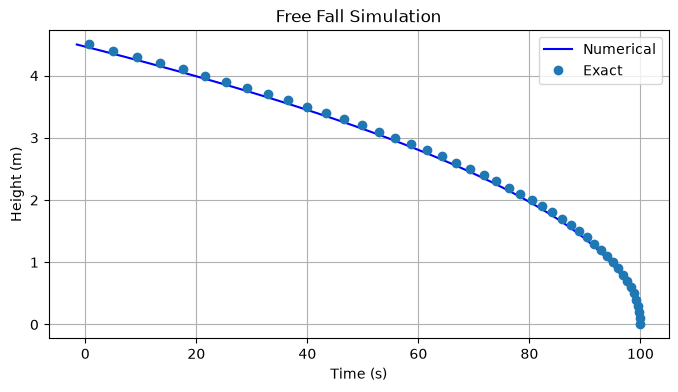

In [4]:
plt.figure(figsize=(8,4))
plt.plot(ys,ts, '-b', label='Numerical')
plt.plot(y_exact,ts, 'o', label='Exact')
plt.xlabel('Time (s)')
plt.ylabel('Height (m)')
plt.title('Free Fall Simulation')
plt.grid(True)
plt.legend()
plt.show()

In [5]:
def simulate_projectile_2d (v0, theta_deg,dt,g):
    x=0
    y=0
    vx=v0*np.cos(np.radians(theta_deg))
    vy=v0*np.sin(np.radians(theta_deg))
    t=0

    #Storage Lists for plotting
    ts, xs, ys, vxs, vys = [0], [0], [0], [v0*np.cos(np.radians(theta_deg))], [v0*np.sin(np.radians(theta_deg))]

    #Euler Loop
        
    while y >= 0:
        ax=0.0
        ay=-g

        #Update Veloctiy
        vy = vy + ay * dt
        vx= vx+ ax*dt
        #Update Position
        x = x + vx * dt
        y = y+ vy * dt
            
        t += dt
        xs.append(x)
        ys.append(y)
        vxs.append(vx)
        vys.append(vy)
        ts.append(t)
    return np.array(ts),np.array(xs), np.array(ys), np.array(vxs), np.array(vys)
v0=30
theta_deg=45

dt = 0.01
g=9.81
ts, xs, ys, vxs, vys = simulate_projectile_2d(v0, theta_deg, dt, g)

range = v0**2 * np.sin(2*np.radians(theta_deg)) / g
max_height = (v0**2 * np.sin(np.radians(theta_deg))**2) / (2*g)
flight_time = 2*v0*np.sin(np.radians(theta_deg))/g

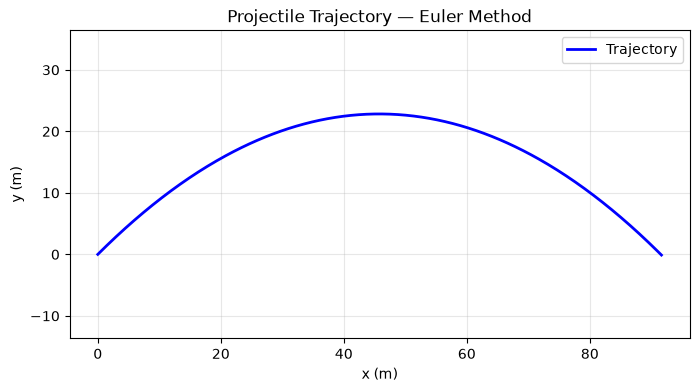

In [6]:
plt.figure(figsize=(8, 4))
plt.plot(xs, ys, 'b-', linewidth=2)
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Projectile Trajectory — Euler Method')
plt.grid(True, alpha=0.3)
plt.legend(['Trajectory'])
plt.axis('equal')
plt.show()


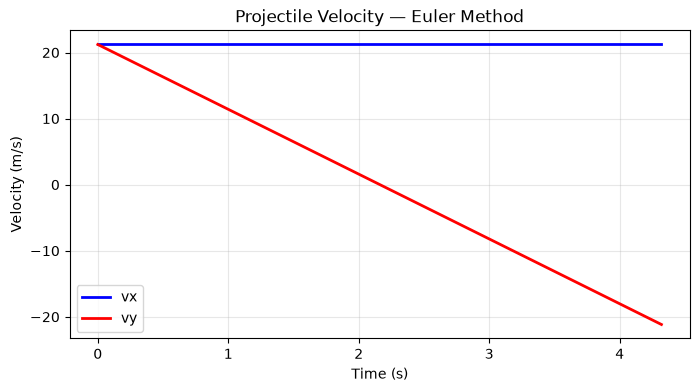

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(ts, vxs, 'b-', label='vx', linewidth=2)
plt.plot(ts, vys, 'r-', label='vy', linewidth=2)
plt.xlabel('Time (s)')
plt.ylabel('Velocity (m/s)')
plt.title('Projectile Velocity — Euler Method')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

The velocity in the x-direction is a horizontal line which is what I expected based on theory, because during projectile motion velocity in the x direction stays constant when drag is considered negligible. The velocity in the y-direction is a negatively sloped and negative which makes since because when drag is assumed negligible, the only force acting on the projectile in the y direction is gravity. The acceleration due to gravity is constant, so when the ball is moving upwards towards its peak, gravity is acting in the direction opposite of the motion so the velocity decreases. At the exact moment the ball changes direction, the velocity is zero which explains why the line crosses the x axis. Then the velocity increased on the way down because gravity is acting in the direction of the motion. 

In [8]:
theta_rad = np.radians(theta_deg)
exact_range = 91.74
exact_max_height = 22.94
exact_flight_time = 4.324
numerical_range = xs[-1]
numerical_max_height = max(ys)
numerical_flight_time = ts[-1]
range_error = abs((exact_range - numerical_range) / exact_range) * 100
height_error = abs((exact_max_height - numerical_max_height) / exact_max_height) * 100
time_error = abs((exact_flight_time - numerical_flight_time) / exact_flight_time) * 100
print(f"range error =", range_error, "%")
print(f"height error =", height_error, "%")
print(f"time error =", time_error, "%")


range error = 0.10787133008887209 %
height error = 0.4803686970864736 %
time error = 0.09250693802145053 %


In [9]:
angles = np.arange(10, 85, 5)
ranges = []
for angle in angles:
    ts, xs, ys, vxs, vys = simulate_projectile_2d(v0, angle, dt, g)

    projectile_range = xs[-1]
    ranges.append(projectile_range)

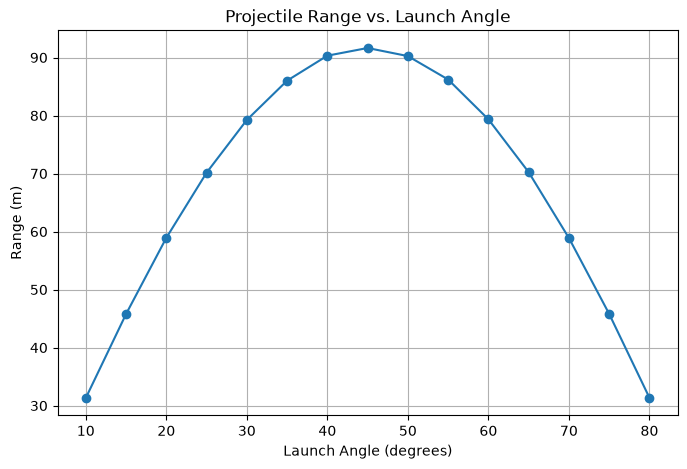

In [10]:
plt.figure(figsize=(8, 5))

plt.plot(angles, ranges, marker="o")

plt.xlabel("Launch Angle (degrees)")
plt.ylabel("Range (m)")
plt.title("Projectile Range vs. Launch Angle")
plt.grid()

plt.show()

In [11]:
def simulate_projectile_drag(v0, theta_deg, dt, g, b_over_m):
    x = 0
    y = 0

    vx = v0 * np.cos(np.radians(theta_deg))
    vy = v0 * np.sin(np.radians(theta_deg))

    t = 0

    ts = [t]
    xs = [x]
    ys = [y]
    vxs = [vx]
    vys = [vy]

    while y >= 0:

        speed = np.sqrt(vx**2 + vy**2)

        # Acceleration with drag
        ax = -(b_over_m) * speed * vx
        ay = -g - (b_over_m) * speed * vy

        # Euler update
        x = x + vx * dt
        y = y + vy * dt

        vx = vx + ax * dt
        vy = vy + ay * dt

        t += dt

        ts.append(t)
        xs.append(x)
        ys.append(y)
        vxs.append(vx)
        vys.append(vy)

    return np.array(ts), np.array(xs), np.array(ys), np.array(vxs), np.array(vys)

In [12]:
v0 = 45
dt = 0.01
g = 9.81
b_over_m = 0.0046
angles = np.arange(10, 85, 5)

ranges_no_drag = []
ranges_drag = []

for angle in angles:

    # No-drag simulation
    ts, xs, ys, vxs, vys = simulate_projectile_2d(
        v0, angle, dt, g
    )
    ranges_no_drag.append(xs[-1])

    # Drag simulation
    ts_d, xs_d, ys_d, vxs_d, vys_d = simulate_projectile_drag(
        v0, angle, dt, g, b_over_m
    )
    ranges_drag.append(xs_d[-1])

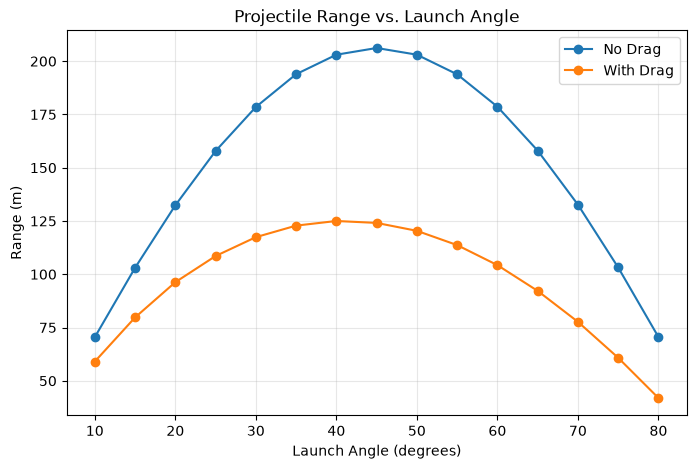

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(angles, ranges_no_drag, 'o-', label='No Drag')
plt.plot(angles, ranges_drag, 'o-', label='With Drag')

plt.xlabel('Launch Angle (degrees)')
plt.ylabel('Range (m)')
plt.title('Projectile Range vs. Launch Angle')
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

With drag, the maximum launch angle is 40 degrees, so it is not 45 degrees. 